# Exploratory Data Analysis Karakteristik Klinis dan Status Penyakit Jantung

### Tujuan EDA: 
memahami kualitas dan karakteristik dataset, mengevaluasi keseimbangan kelas target, serta mengeksplorasi perbedaan distribusi atribut klinis antara kelompok target = 0 dan target = 1. Analisis ini juga bertujuan mengidentifikasi missing value, duplikasi, pencilan, dan pola hubungan antarvariabel sebelum dataset digunakan untuk pemodelan klasifikasi.

### Data Dictionary
- age (usia): Usia pasien dalam satuan tahun.
- sex (jenis kelamin): Jenis kelamin pasien.

    - 1 = laki-laki
    - 0 = perempuan

- cp (tipe nyeri dada): Jenis nyeri dada yang dialami pasien.

    - 0 = tanpa gejala (asymptomatic)
    - 1 = angina atipikal (atypical angina)
    - 2 = nyeri non-angina (non-anginal pain)
    - 3 = angina tipikal (typical angina)

- trestbps (tekanan darah saat istirahat): Tekanan darah pasien saat istirahat, diukur dalam satuan mmHg ketika pasien masuk rumah sakit.

- chol (kolesterol): Kadar kolesterol serum pasien dalam satuan mg/dL.

- fbs (gula darah puasa): Menunjukkan apakah kadar gula darah puasa pasien lebih besar dari 120 mg/dL.

    - 1 = benar, gula darah puasa lebih dari 120 mg/dL
    - 0 = salah, gula darah puasa tidak lebih dari 120 mg/dL

- restecg (hasil elektrokardiografi saat istirahat): Hasil pemeriksaan elektrokardiografi atau EKG pasien dalam kondisi istirahat.

    - 0 = menunjukkan kemungkinan atau kepastian hipertrofi ventrikel kiri berdasarkan kriteria Estes
    - 1 = normal
    - 2 = terdapat kelainan gelombang ST-T, berupa inversi gelombang T dan/atau elevasi atau depresi segmen ST lebih dari 0,05 mV

- thalach (denyut jantung maksimum): Denyut jantung maksimum yang berhasil dicapai pasien.

- exang (angina akibat olahraga): Menunjukkan apakah pasien mengalami angina atau nyeri dada yang dipicu oleh aktivitas fisik.

    - 1 = ya
    - 0 = tidak

- oldpeak (depresi segmen ST): Besarnya depresi segmen ST yang dipicu oleh aktivitas fisik dibandingkan dengan kondisi istirahat.

- slope (kemiringan segmen ST): Bentuk kemiringan segmen ST pada puncak aktivitas fisik.

    - 0 = menurun (downsloping)
    - 1 = datar (flat)
    - 2 = menanjak (upsloping)

- ca (jumlah pembuluh darah utama): Jumlah pembuluh darah utama yang terlihat atau terwarnai melalui pemeriksaan fluoroskopi, dengan rentang nilai 0–3.

- thal (hasil pemeriksaan thalium): Kategori kondisi berdasarkan hasil pemeriksaan thalium stress test.

    - 0 = kesalahan atau data tidak valid. Pada dataset asli, nilai ini dipetakan sebagai nilai kosong atau NaN
    - 1 = cacat tetap (fixed defect)
    - 2 = normal
    - 3 = cacat reversibel (reversible defect)

- target (label/status penyakit): Variabel keluaran yang menunjukkan status penyakit jantung pasien.

    - 0 = terindikasi penyakit jantung
    - 1 = tidak terindikasi penyakit jantung

### Referensi Analisis
kaggle link: https://www.kaggle.com/code/desalegngeb/heart-disease-predictions 
. Notebook kaggle digunakan sebagai referensi alur analisis. Seluruh statistik, visualisasi, dan kesimpulan dalam notebook ini dihitung kembali menggunakan dataset yang dianalisis.

### Validasi Data Dictionary (Label Target dan Kode Kategori)

Pemeriksaan awal terhadap pola data menunjukkan bahwa kode pada dataset ini tidak mengikuti urutan kode pada dokumentasi UCI. Pada `data_clean`, `target = 1` justru paling sering muncul pada pasien perempuan (75% dibanding 44% pada laki-laki), pasien tanpa angina akibat olahraga (69% dibanding 24%), dan pasien dengan `ca = 0` (75% dibanding 15–32% pada `ca` ≥ 1). Pola tersebut berlawanan dengan arah risiko klinis apabila `target = 1` dianggap sebagai terindikasi penyakit jantung.

Untuk memastikannya, 302 baris unik pada dataset ini dicocokkan satu per satu dengan file `processed.cleveland.data` dari UCI Heart Disease (Cleveland, <https://archive.ics.uci.edu/dataset/45/heart-disease>). Kunci pencocokan adalah atribut yang kodenya identik, yaitu `age`, `sex`, `trestbps`, `chol`, `fbs`, `thalach`, `exang`, dan `oldpeak`. Seluruh 302 baris cocok tanpa ambiguitas, kemudian kode atribut lainnya dibandingkan.

| Atribut | Kode pada dataset ini | Kode pada UCI asli |
|---|---|---|
| `target` | 0 = terindikasi penyakit (138 baris), 1 = tidak terindikasi (164 baris) | `num` > 0 dan `num` = 0 |
| `cp` | 0 = asymptomatic, 1 = atypical angina, 2 = non-anginal, 3 = typical angina | 4, 2, 3, 1 |
| `restecg` | 0 = hipertrofi ventrikel kiri, 1 = normal, 2 = kelainan ST-T | 2, 0, 1 |
| `slope` | 0 = downsloping, 1 = flat, 2 = upsloping | 3, 2, 1 |
| `thal` | 1 = fixed defect, 2 = normal, 3 = reversible defect | 6, 3, 7 |
| `sex`, `fbs`, `exang`, `ca` | sama dengan dokumentasi | sama |

Seluruh 164 baris dengan `target = 1` berasal dari `num = 0` (tidak ada penyakit) dan seluruh 138 baris dengan `target = 0` berasal dari `num` > 0. Pencocokan ini juga menunjukkan bahwa `ca = 4` dan `thal = 0` adalah nilai yang hilang (`?`) pada data UCI asli, sehingga keputusan untuk memperlakukannya sebagai NaN pada bagian Data Cleaning sudah tepat.

### 1. Konteks Dataset

In [2]:
import pandas as pd

data_dictionary = pd.DataFrame({
    "Atribut": [
        "age", "sex", "cp", "trestbps", "chol", "fbs",
        "restecg", "thalach", "exang", "oldpeak",
        "slope", "ca", "thal", "target"
    ],
    "Peran analisis": [
        "Numerik kontinu/diskrit",
        "Kategorikal biner",
        "Kategorikal",
        "Numerik kontinu",
        "Numerik kontinu",
        "Kategorikal biner",
        "Kategorikal",
        "Numerik kontinu",
        "Kategorikal biner",
        "Numerik kontinu",
        "Kategorikal ordinal",
        "Kategorikal ordinal/diskrit",
        "Kategorikal",
        "Target biner"
    ]
})

data_dictionary

,Atribut,Peran analisis
0,age,Numerik kontinu/diskrit
1,sex,Kategorikal biner
2,cp,Kategorikal
3,trestbps,Numerik kontinu
4,chol,Numerik kontinu
5,fbs,Kategorikal biner
6,restecg,Kategorikal
7,thalach,Numerik kontinu
8,exang,Kategorikal biner
9,oldpeak,Numerik kontinu


In [3]:
continuous_cols = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

In [4]:
categorical_cols = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

In [5]:
target_col = "target"

In [ ]:
category_labels = {
    "sex":     {0: "perempuan", 1: "laki-laki"},
    "cp":      {0: "asymptomatic", 1: "atypical angina", 2: "non-anginal", 3: "typical angina"},
    "fbs":     {0: "≤120", 1: ">120"},
    "restecg": {0: "LVH", 1: "normal", 2: "ST-T abnormal"},
    "exang":   {0: "tidak", 1: "ya"},
    "slope":   {0: "downsloping", 1: "flat", 2: "upsloping"},
    "ca":      {0: "0", 1: "1", 2: "2", 3: "3"},
    "thal":    {1: "fixed defect", 2: "normal", 3: "reversible defect"},
}

target_labels = {0: "terindikasi penyakit", 1: "tidak terindikasi"}


def tick_label(col, code, wrap=True):
    name = category_labels[col][code]
    if name == str(code):
        return str(code)
    return f"{code}\n{name.replace(' ', chr(10)) if wrap else name}"

### 2. Import Library dan Analisis Awal Data

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import (
    mannwhitneyu,
    chi2_contingency
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

In [8]:
data_raw = pd.read_csv("heart_disease_dataset.csv")
data = data_raw.copy()
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.00,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.10,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.60,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.00,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.90,1,3,2,0


In [9]:
data.shape

(1025, 14)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [11]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00
mean,54.43,0.70,0.94,131.61,246.00,0.15,0.53,149.11,0.34,1.07,1.39,0.75,2.32,0.51
std,9.07,0.46,1.03,17.52,51.59,0.36,0.53,23.01,0.47,1.18,0.62,1.03,0.62,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,0.00,120.00,211.00,0.00,0.00,132.00,0.00,0.00,1.00,0.00,2.00,0.00
50%,56.00,1.00,1.00,130.00,240.00,0.00,1.00,152.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,275.00,0.00,1.00,166.00,1.00,1.80,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


In [12]:
print(data.columns.tolist())

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [13]:
data.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Dataset penyakit jantung terdiri atas 1.025 baris dan 14 kolom. Setiap baris merepresentasikan satu observasi pasien, sedangkan setiap kolom memuat karakteristik klinis pasien. Atribut numerik kontinu dalam dataset meliputi age, trestbps, chol, thalach, dan oldpeak. Sementara itu, sex, cp, fbs, restecg, exang, slope, ca, thal, dan target merupakan atribut kategorikal atau diskrit yang direpresentasikan menggunakan kode angka.

Hasil data.info() menunjukkan bahwa seluruh atribut terbaca sebagai data numerik, dengan 13 atribut bertipe int64 dan satu atribut, yaitu oldpeak, bertipe float64. Namun, tipe int64 tidak selalu menunjukkan bahwa suatu atribut merupakan variabel numerik kontinu. Atribut seperti cp, restecg, slope, ca, dan thal tetap merupakan kategori berkode karena setiap angka menunjukkan kelompok atau kondisi klinis tertentu. Oleh karena itu, atribut tersebut lebih tepat dianalisis menggunakan frekuensi dan proporsi, bukan hanya menggunakan nilai rata-rata atau operasi numerik lainnya.

### 3. Analisis Kualita Data

In [14]:
missing_summary = pd.DataFrame({
    "Jumlah Missing": data.isna().sum(),
    "Persentase (%)": (
        data.isna().mean() * 100
    ).round(2)
})

missing_summary

,Jumlah Missing,Persentase (%)
age,0,0.00
sex,0,0.00
cp,0,0.00
trestbps,0,0.00
chol,0,0.00
fbs,0,0.00
restecg,0,0.00
thalach,0,0.00
exang,0,0.00
oldpeak,0,0.00


In [15]:
data_duplikat = data.duplicated().sum()
presentase_duplikat = (
    data_duplikat / len(data) * 100
)

print("Jumlah data:", len(data))
print("Jumlah duplikat:", data_duplikat)
print(
    "Persentase duplikat:",
    round(presentase_duplikat, 2),
    "%"
)

Jumlah data: 1025
Jumlah duplikat: 723
Persentase duplikat: 70.54 %


In [16]:
data[data.duplicated(keep=False)].head(20)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.00,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.10,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.60,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.00,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.90,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.00,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.40,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.80,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.80,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.20,1,2,2,0


In [17]:
data_unique = (
    data
    .drop_duplicates()
    .copy()
)

print("Sebelum:", data.shape)
print("Sesudah:", data_unique.shape)

Sebelum: (1025, 14)
Sesudah: (302, 14)


In [18]:
perbandingan_target = pd.concat(
    [
        data["target"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .rename("Sebelum (%)"),

        data_unique["target"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .rename("Sesudah (%)")
    ],
    axis=1
).round(2)

perbandingan_target["Perubahan Poin Persentase"] = (
    perbandingan_target["Sesudah (%)"]
    - perbandingan_target["Sebelum (%)"]
)

perbandingan_target


,Sebelum (%),Sesudah (%),Perubahan Poin Persentase
target,,,
0,48.68,45.70,-2.98
1,51.32,54.30,2.98


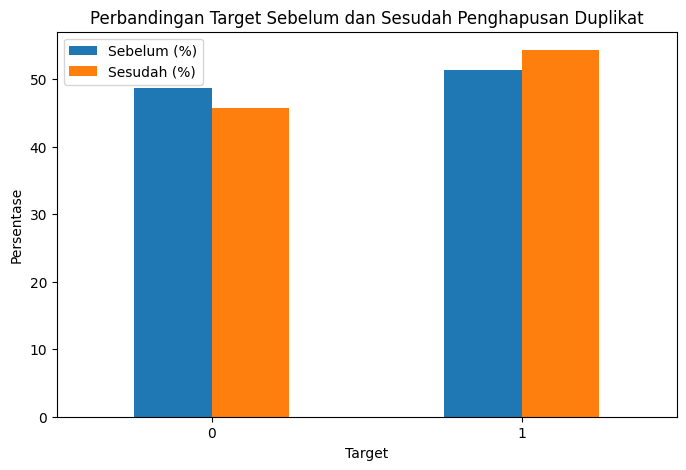

In [ ]:
perbandingan_target[
    ["Sebelum (%)", "Sesudah (%)"]
].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Perbandingan Target Sebelum dan Sesudah Penghapusan Duplikat")
plt.xlabel("Target")
plt.ylabel("Persentase")
plt.xticks(rotation=0)
plt.show()

Hasil pemeriksaan menunjukkan bahwa terdapat 723 baris duplikat dari 1.025 observasi, atau sekitar 70,54% dari keseluruhan dataset. Setelah baris identik dihapus, tersisa 302 observasi unik. Jumlah duplikasi yang tinggi berpotensi memberikan bobot berulang terhadap kombinasi karakteristik klinis tertentu sehingga dapat memengaruhi distribusi, statistik deskriptif, korelasi, visualisasi, dan pemodelan. Namun, karena dataset tidak memiliki identitas unik pasien, baris yang identik belum tentu berasal dari pasien yang sama dan masih mungkin merepresentasikan pasien berbeda dengan karakteristik klinis yang sama. Oleh karena itu, penghapusan duplikat dilakukan untuk mencegah kombinasi atribut identik memperoleh bobot berulang, bukan untuk menyatakan bahwa seluruh baris tersebut pasti merupakan kesalahan pencatatan. Sebelum penghapusan duplikat, proporsi target = 0 dan target = 1 masing-masing sebesar 48,68% dan 51,32%. Setelah duplikat dihapus, proporsinya berubah menjadi 45,70% dan 54,30%, atau berubah sebesar 2,98 poin persentase pada masing-masing kelas. Perubahan ini tidak membalik kelas dominan dan distribusi target tetap relatif tidak timpang secara ekstrem.

### 4. Data Cleaning

In [20]:
for col in categorical_cols:
    print(
        f"{col}:",
        sorted(data_unique[col].dropna().unique())
    )

sex: [np.int64(0), np.int64(1)]
cp: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
fbs: [np.int64(0), np.int64(1)]
restecg: [np.int64(0), np.int64(1), np.int64(2)]
exang: [np.int64(0), np.int64(1)]
slope: [np.int64(0), np.int64(1), np.int64(2)]
ca: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
thal: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [21]:
data_clean = data_unique.copy()

data_clean["ca"] = (
    data_clean["ca"]
    .replace(4, np.nan)
)

data_clean["thal"] = (
    data_clean["thal"]
    .replace(0, np.nan)
)

In [22]:
data_clean[["ca", "thal"]].isna().sum()

ca      4
thal    2
dtype: int64

In [23]:
data_clean = (data_clean.dropna(subset=["ca", "thal"]).copy())

data_clean["ca"] = data_clean["ca"].astype(int)
data_clean["thal"] = data_clean["thal"].astype(int)

In [24]:
valid_values = {
    "sex": {0, 1},
    "cp": {0, 1, 2, 3},
    "fbs": {0, 1},
    "restecg": {0, 1, 2},
    "exang": {0, 1},
    "slope": {0, 1, 2},
    "ca": {0, 1, 2, 3},
    "thal": {1, 2, 3},
    "target": {0, 1}
}

validation_results = []

for col, valid_set in valid_values.items():
    actual_set = set(data_clean[col].dropna().unique())

    invalid_set = actual_set - valid_set

    validation_results.append({
        "Atribut": col,
        "Nilai Ditemukan": sorted(actual_set),
        "Nilai Tidak Valid": sorted(invalid_set),
        "Status": (
            "Valid"
            if len(invalid_set) == 0
            else "Perlu Diperiksa"
        )
    })

validation_df = pd.DataFrame(validation_results)
validation_df

,Atribut,Nilai Ditemukan,Nilai Tidak Valid,Status
0,sex,"[0, 1]",[],Valid
1,cp,"[0, 1, 2, 3]",[],Valid
2,fbs,"[0, 1]",[],Valid
3,restecg,"[0, 1, 2]",[],Valid
4,exang,"[0, 1]",[],Valid
5,slope,"[0, 1, 2]",[],Valid
6,ca,"[0, 1, 2, 3]",[],Valid
7,thal,"[1, 2, 3]",[],Valid
8,target,"[0, 1]",[],Valid


In [25]:
print("Ukuran awal:", data_raw.shape)
print("Setelah menghapus duplikat:", data_unique.shape)
print("Ukuran final:", data_clean.shape)
print("Duplikat tersisa:", data_clean.duplicated().sum())
print("Missing value tersisa:", data_clean.isna().sum().sum())

Ukuran awal: (1025, 14)
Setelah menghapus duplikat: (302, 14)
Ukuran final: (296, 14)
Duplikat tersisa: 0
Missing value tersisa: 0


In [26]:
data_clean.to_csv("heart_disease_clean.csv", index=False)

Dataset awal terdiri atas 1.025 observasi dan 14 atribut. Pemeriksaan duplikasi menemukan 723 baris identik, sehingga setelah duplikat dihapus, tersisa 302 observasi unik. Selanjutnya, ditemukan 4 observasi dengan ca = 4, padahal nilai ca yang valid menurut data dictionary berada pada rentang 0 sampai 3. Selain itu, terdapat 2 observasi denganthal = 0, yang didefinisikan sebagai nilai kesalahan atau data tidak valid. Keenam observasi tersebut kemudian dikeluarkan melalui pendekatan complete-case analysis. Dengan demikian, dataset akhir yang digunakan dalam analisis terdiri atas 296 observasi dan 14 atribut, tanpa duplikasi, nilai kosong, maupun kategori yang tidak valid.

Data mentah tetap disimpan dalam variabel data_raw dan tidak ditimpa agar informasi asli tetap tersedia, proses pembersihan dapat ditelusuri, serta hasil sebelum dan sesudah pembersihan dapat dibandingkan. Sementara itu, data_unique digunakan sebagai data antara setelah penghapusan duplikat, sedangkan data_clean digunakan sebagai dataset final setelah seluruh nilai tidak valid ditangani. Oleh karena itu, seluruh statistik, tabel, visualisasi, deteksi outlier, dan analisis hubungan pada tahap selanjutnya menggunakan data_clean agar hasil analisis konsisten dan tidak dipengaruhi oleh pengulangan maupun kategori yang tidak sesuai.

### 5. EDA Univariat

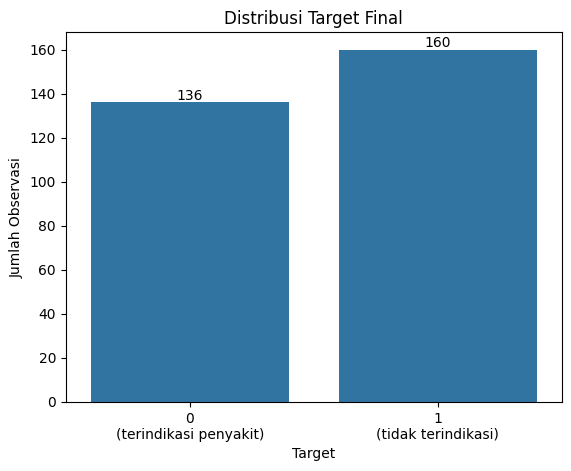

In [27]:
ax = sns.countplot(
    data=data_clean,
    x="target"
)

for container in ax.containers:
    ax.bar_label(container)

ax.set_xticks([0, 1])
ax.set_xticklabels([f"{k}\n({target_labels[k]})" for k in (0, 1)])

plt.title("Distribusi Target Final")
plt.xlabel("Target")
plt.ylabel("Jumlah Observasi")
plt.show()

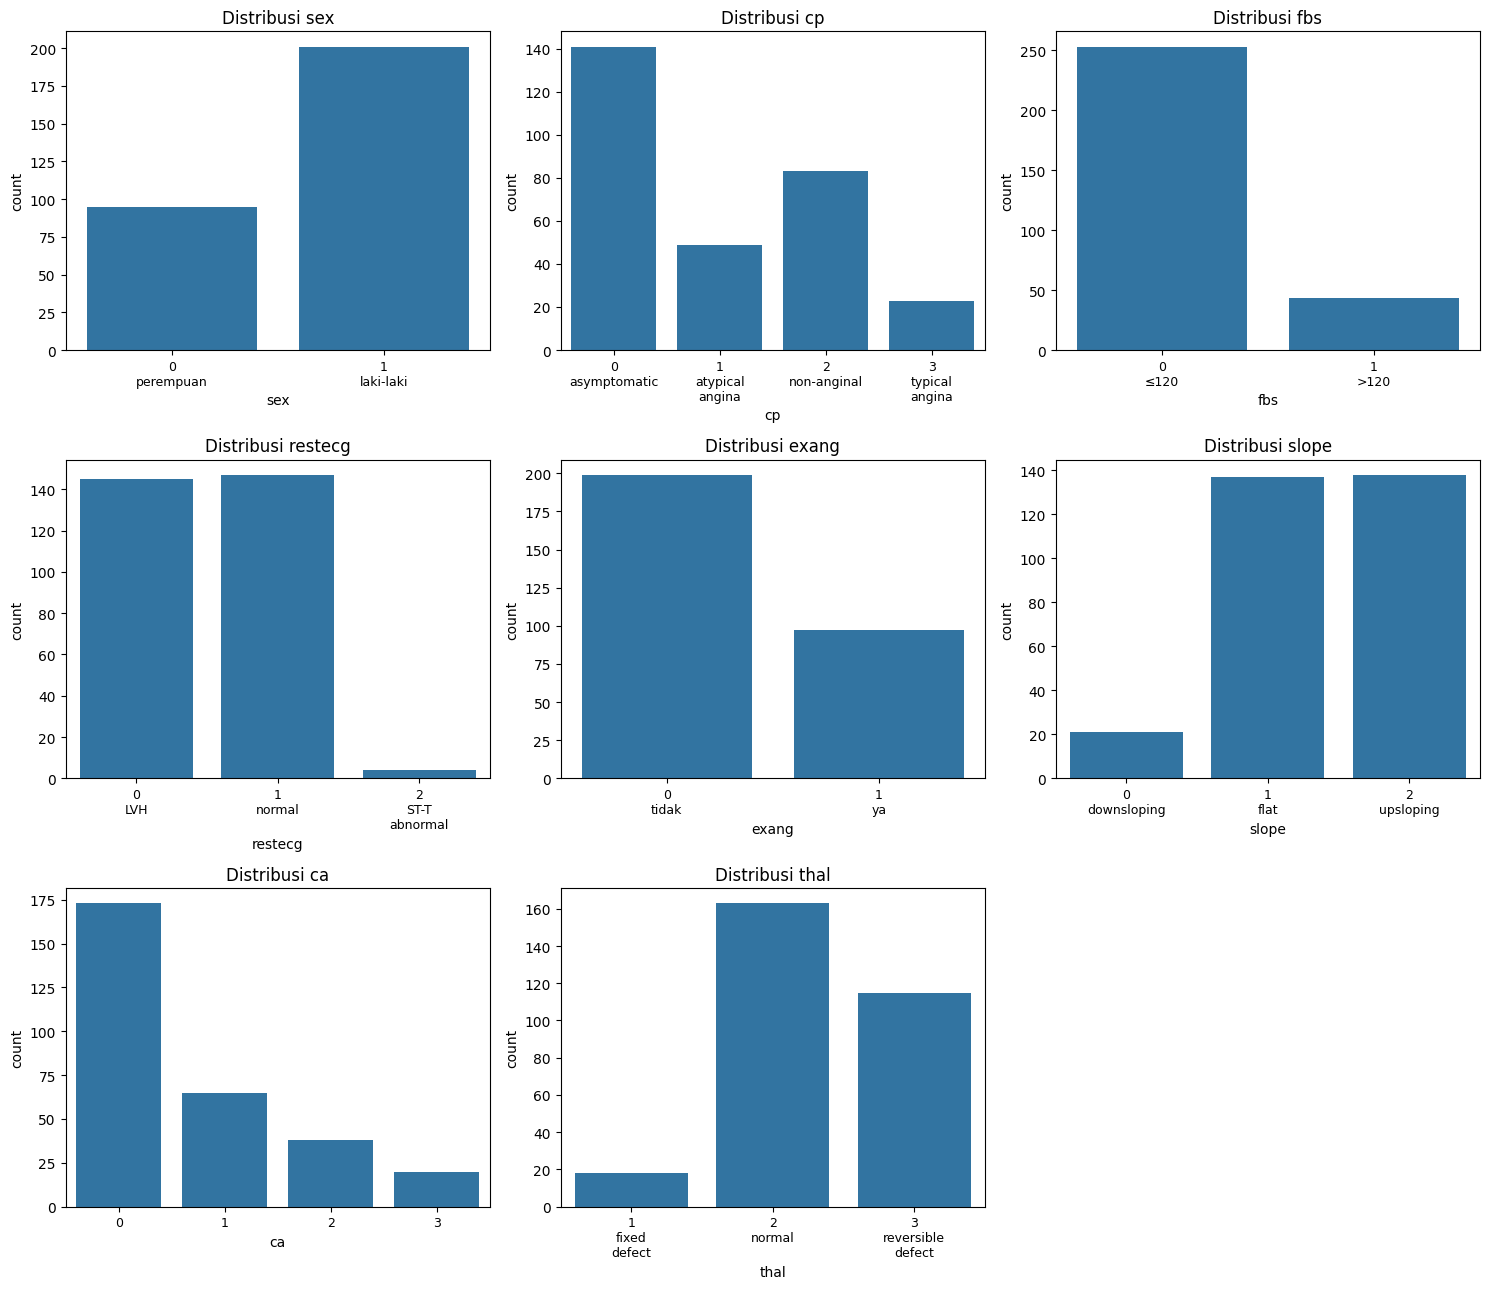

In [28]:
fig, axes = plt.subplots(
    3, 3,
    figsize=(15, 13)
)

axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(
        data=data_clean,
        x=col,
        ax=axes[i]
    )

    codes = sorted(data_clean[col].unique())
    axes[i].set_xticks(range(len(codes)))
    axes[i].set_xticklabels(
        [tick_label(col, c) for c in codes],
        fontsize=9
    )

    axes[i].set_title(
        f"Distribusi {col}"
    )

axes[-1].axis("off")

plt.tight_layout()
plt.show()

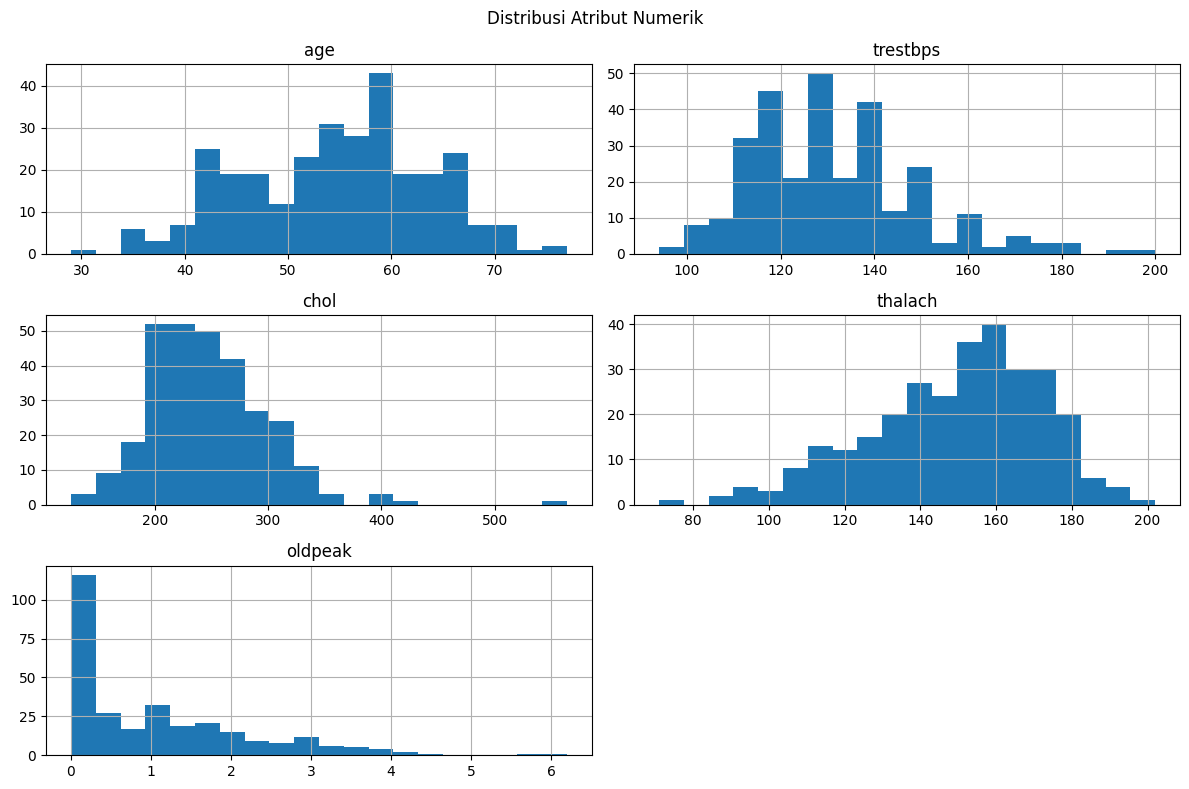

In [29]:
data_clean[continuous_cols].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle(
    "Distribusi Atribut Numerik"
)

plt.tight_layout()
plt.show()

### 6. EDA Bivariat Berdasarkan Target

In [30]:
continuous_by_target = (
    data_clean
    .groupby("target")[continuous_cols]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
    .round(2)
)

continuous_by_target

age                           trestbps                                \
       count  mean median  std min max    count   mean median   std  min  max   
target                                                                          
0        136 56.74  58.00 7.92  35  77      136 134.46 130.00 18.86  100  200   
1        160 52.64  52.00 9.55  29  76      160 129.18 130.00 16.37   94  180   

        chol                               thalach                          \
       count   mean median   std  min  max   count   mean median   std min   
target                                                                       
0        136 251.46 251.00 49.65  131  409     136 138.95 141.50 22.72  71   
1        160 243.49 235.50 53.76  126  564     160 158.58 161.00 19.04  96   

            oldpeak                             
        max   count mean median  std  min  max  
target                                          
0       195     136 1.60   1.40 1.30 0.00 6.20  
1       202     160 0.60   0.20 0.79 0.00 4.20

In [31]:
median_by_target = (
    data_clean
    .groupby("target")[continuous_cols]
    .median()
    .T
)

median_by_target[
    "Selisih Target 1 - Target 0"
] = (
    median_by_target[1]
    - median_by_target[0]
)

median_by_target.round(2)

target,0,1,Selisih Target 1 - Target 0
age,58.00,52.00,-6.00
trestbps,130.00,130.00,0.00
chol,251.00,235.50,-15.50
thalach,141.50,161.00,19.50
oldpeak,1.40,0.20,-1.20


In [32]:
outlier_results = []

for col in continuous_cols:
    q1 = data_clean[col].quantile(0.25)
    q3 = data_clean[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (
        (data_clean[col] < lower_bound)
        |
        (data_clean[col] > upper_bound)
    )

    outlier_results.append({
        "Atribut": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Batas Bawah": lower_bound,
        "Batas Atas": upper_bound,
        "Jumlah Outlier": outlier_mask.sum(),
        "Persentase Outlier": (
            outlier_mask.mean() * 100
        )
    })

outlier_summary = pd.DataFrame(
    outlier_results
).round(2)

outlier_summary

,Atribut,Q1,Q3,IQR,Batas Bawah,Batas Atas,Jumlah Outlier,Persentase Outlier
0,age,48.00,61.00,13.00,28.50,80.50,0,0.00
1,trestbps,120.00,140.00,20.00,90.00,170.00,9,3.04
2,chol,211.00,275.25,64.25,114.62,371.62,5,1.69
3,thalach,133.00,166.00,33.00,83.50,215.50,1,0.34
4,oldpeak,0.00,1.65,1.65,-2.48,4.12,5,1.69



Proporsi target berdasarkan sex


target,0,1
sex,,
0,25.26,74.74
1,55.72,44.28


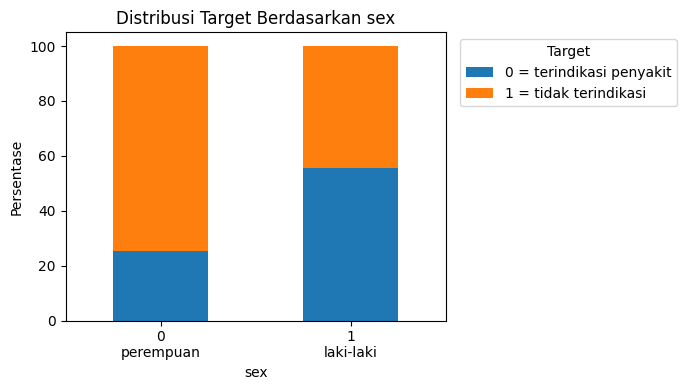


Proporsi target berdasarkan cp


target,0,1
cp,,
0,72.34,27.66
1,18.37,81.63
2,21.69,78.31
3,30.43,69.57


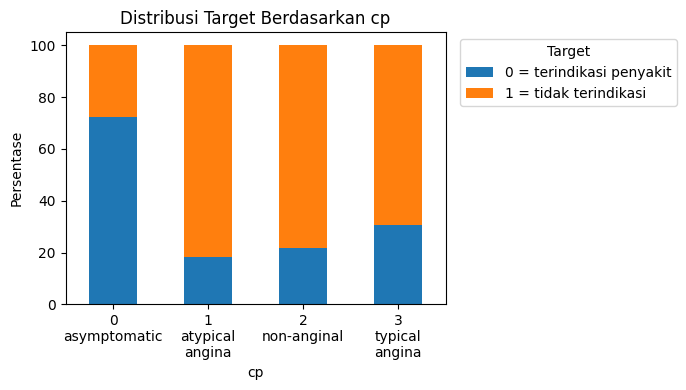


Proporsi target berdasarkan fbs


target,0,1
fbs,,
0,45.85,54.15
1,46.51,53.49


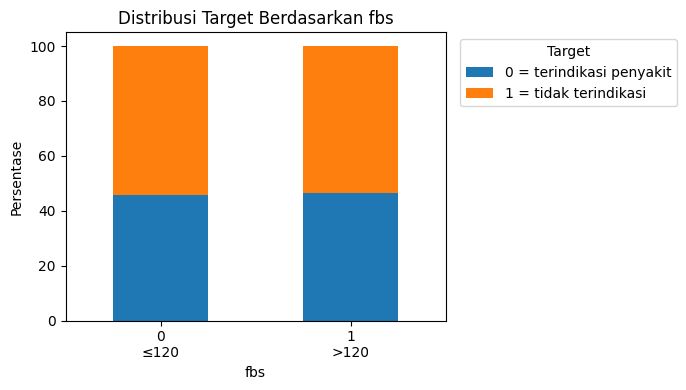


Proporsi target berdasarkan restecg


target,0,1
restecg,,
0,53.79,46.21
1,37.41,62.59
2,75.00,25.00


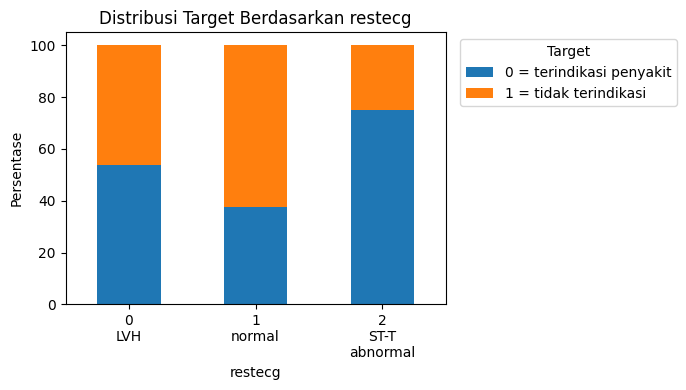


Proporsi target berdasarkan exang


target,0,1
exang,,
0,31.16,68.84
1,76.29,23.71


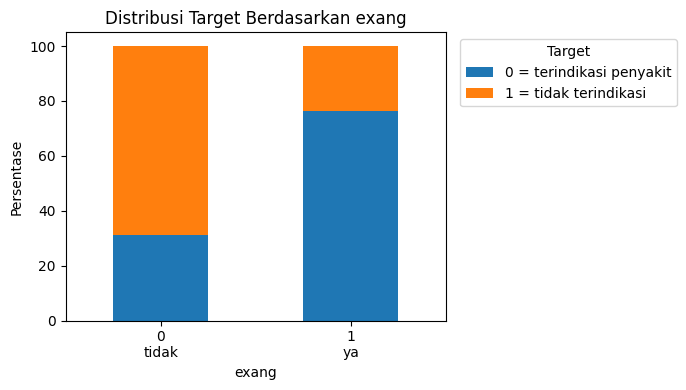


Proporsi target berdasarkan slope


target,0,1
slope,,
0,57.14,42.86
1,64.96,35.04
2,25.36,74.64


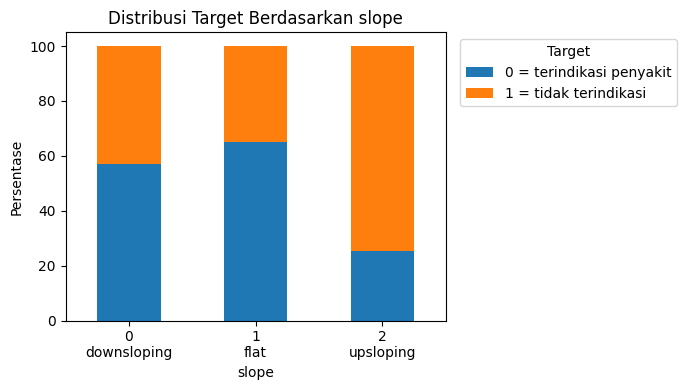


Proporsi target berdasarkan ca


target,0,1
ca,,
0,25.43,74.57
1,67.69,32.31
2,81.58,18.42
3,85.00,15.00


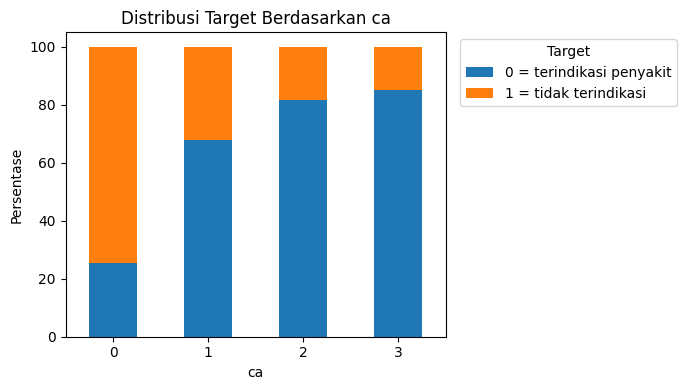


Proporsi target berdasarkan thal


target,0,1
thal,,
1,66.67,33.33
2,22.09,77.91
3,76.52,23.48


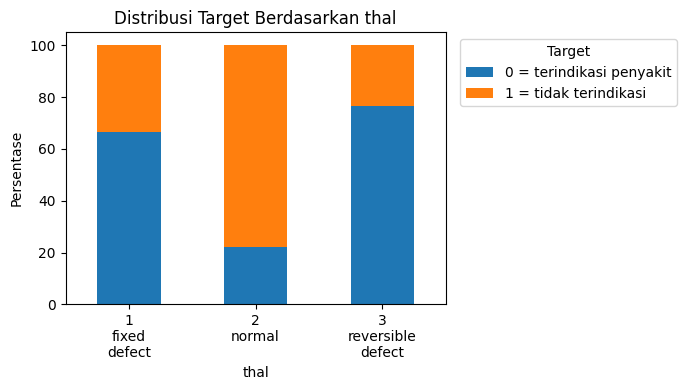

In [33]:
for col in categorical_cols:
    proportion = pd.crosstab(
        data_clean[col],
        data_clean["target"],
        normalize="index"
    ).mul(100).round(2)

    print(
        f"\nProporsi target berdasarkan {col}"
    )

    display(proportion)

    proportion.plot(
        kind="bar",
        stacked=True,
        figsize=(7, 4)
    )

    plt.title(
        f"Distribusi Target Berdasarkan {col}"
    )

    plt.xlabel(col)
    plt.ylabel("Persentase")
    plt.legend(
        title="Target",
        labels=[f"0 = {target_labels[0]}", f"1 = {target_labels[1]}"],
        loc="upper left",
        bbox_to_anchor=(1.02, 1)
    )
    plt.xticks(
        range(len(proportion)),
        [tick_label(col, c) for c in proportion.index],
        rotation=0
    )
    plt.tight_layout()
    plt.show()

Berdasarkan histogram dan statistik deskriptif pada data_clean, variabel age dan thalach memiliki distribusi yang relatif lebih simetris dibandingkan variabel lainnya, karena data terkonsentrasi di sekitar nilai tengah dan perbedaan antara mean serta median tidak terlalu besar. Distribusi thalach menunjukkan sedikit kecenderungan miring ke kiri karena terdapat beberapa nilai rendah, sedangkan trestbps cenderung sedikit miring ke kanan akibat beberapa nilai tekanan darah yang tinggi. Distribusi chol dan terutama oldpeak menunjukkan kemencengan ke kanan yang lebih jelas karena mayoritas observasi berada pada nilai rendah hingga menengah, tetapi terdapat sejumlah kecil nilai yang jauh lebih tinggi. Indikasi nilai ekstrem ditemukan pada trestbps sebanyak 9 observasi, chol sebanyak 5 observasi, thalach sebanyak 1 observasi, dan oldpeak sebanyak 5 observasi, sedangkan age tidak memiliki outlier berdasarkan metode IQR. Perbedaan mean dan median pada age, trestbps, dan thalach relatif kecil, sedangkan perbedaan pada chol dan khususnya oldpeak lebih terlihat akibat distribusinya yang miring ke kanan. Meskipun demikian, nilai ekstrem tersebut tidak langsung dihapus karena pada data klinis masih mungkin merepresentasikan kondisi pasien yang valid dan bukan kesalahan pencatatan.

### 7. EDA Multivariat dan Analisis Asosiasi Tujuan

In [34]:
association_results = []

for col in categorical_cols:
    contingency_table = pd.crosstab(
        data_clean[col],
        data_clean["target"]
    )

    chi2, p_value, dof, expected = (
        chi2_contingency(contingency_table)
    )

    n = contingency_table.to_numpy().sum()
    min_dimension = (
        min(contingency_table.shape) - 1
    )

    cramers_v = np.sqrt(
        chi2 / (n * min_dimension)
    )

    association_results.append({
        "Atribut": col,
        "Chi-Square": chi2,
        "p-value": p_value,
        "Cramer's V": cramers_v,
        "Expected Minimum": expected.min()
    })

association_summary = (
    pd.DataFrame(association_results)
    .sort_values(
        "Cramer's V",
        ascending=False
    )
    .round(4)
)

association_summary

,Atribut,Chi-Square,p-value,Cramer's V,Expected Minimum
7,thal,83.76,0.00,0.53,8.27
1,cp,76.45,0.00,0.51,10.57
6,ca,73.40,0.00,0.50,9.19
4,exang,51.68,0.00,0.42,44.57
5,slope,44.55,0.00,0.39,9.65
0,sex,22.89,0.00,0.28,43.65
3,restecg,9.26,0.01,0.18,1.84
2,fbs,0.00,1.00,0.00,19.76


Berdasarkan analisis Chi-Square dan Cramér’s V pada data_clean, atribut kategorikal yang memiliki asosiasi paling kuat dengan target adalah thal dengan Cramér’s V sebesar 0,532, diikuti cp sebesar 0,508, ca sebesar 0,498, exang sebesar 0,418, dan slope sebesar 0,388. Seluruh atribut tersebut memiliki p-value yang ditampilkan sebesar 0,0000, sehingga menunjukkan adanya hubungan statistik dengan status target pada dataset ini. Atribut sex menunjukkan asosiasi yang lebih lemah dengan Cramér’s V sebesar 0,278, sedangkan restecg memiliki asosiasi lemah sebesar 0,177 dengan p-value 0,0097. Namun, hasil restecg perlu ditafsirkan secara hati-hati karena nilai frekuensi harapan minimumnya hanya 1,8378, lebih kecil dari 5, sehingga asumsi uji Chi-Square belum sepenuhnya terpenuhi. Sementara itu, fbs memiliki Cramér’s V sebesar 0,000 dan p-value 1,000, sehingga tidak menunjukkan asosiasi dengan target pada data yang dianalisis.

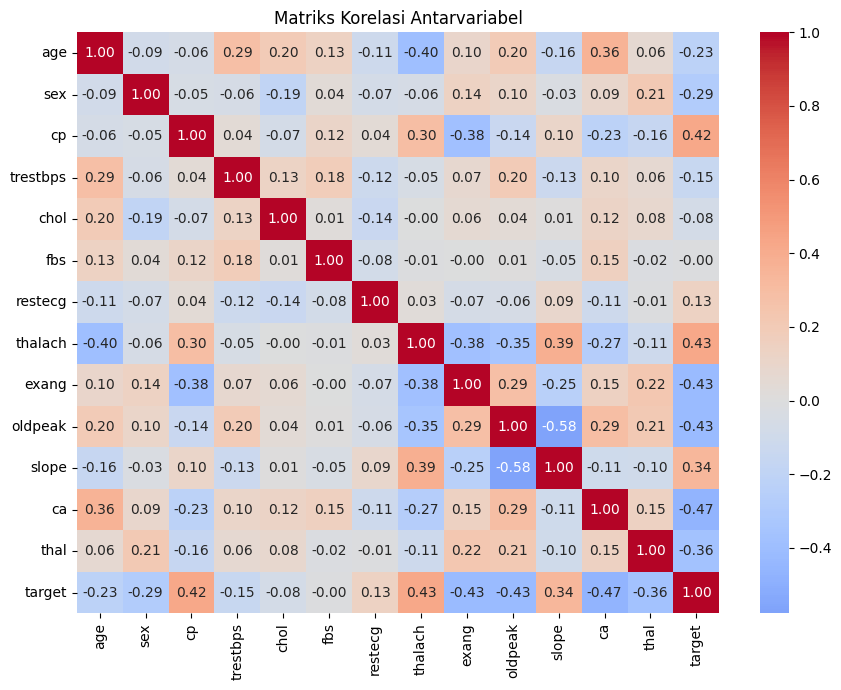

In [35]:
plt.figure(figsize=(9, 7))

correlation_matrix = (
    data_clean
    .corr(numeric_only=True)
)

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title(
    "Matriks Korelasi Antarvariabel"
)

plt.tight_layout()
plt.show()

In [36]:
target_correlation = (
    correlation_matrix["target"]
    .drop("target")
    .sort_values(
        key=abs,
        ascending=False
    )
)

target_correlation

ca         -0.47
oldpeak    -0.43
thalach     0.43
exang      -0.43
cp          0.42
thal       -0.36
slope       0.34
sex        -0.29
age        -0.23
trestbps   -0.15
restecg     0.13
chol       -0.08
fbs        -0.00
Name: target, dtype: float64

Matriks korelasi menunjukkan bahwa atribut dengan korelasi terbesar terhadap target adalah ca sebesar −0,467, diikuti oldpeak sebesar −0,429, thalach sebesar 0,427, exang sebesar −0,425, dan cp sebesar 0,423. Karena target = 1 berarti tidak terindikasi penyakit jantung, korelasi negatif pada ca, oldpeak, dan exang menunjukkan bahwa nilai yang lebih tinggi lebih sering ditemukan pada pasien terindikasi penyakit jantung (target = 0), sedangkan korelasi positif pada thalach menunjukkan bahwa denyut jantung maksimum yang lebih tinggi lebih sering ditemukan pada pasien tanpa indikasi penyakit. Korelasi cp tidak dapat dibaca sebagai hubungan “semakin besar kode, semakin besar target” karena cp merupakan kategori nominal berkode angka. Berdasarkan tabel proporsi, pasien dengan cp = 0 (asymptomatic) paling sering terindikasi penyakit jantung (target = 0), sedangkan pasien dengan cp = 1 sampai 3 lebih sering berada pada target = 1. Sebaliknya, fbs, chol, restecg, dan trestbps memiliki korelasi yang relatif lemah dengan target. Karena beberapa atribut seperti cp, restecg, slope, ca, dan thal merupakan kategori berkode angka, korelasi Pearson pada atribut tersebut hanya digunakan sebagai indikasi eksploratif dan perlu dibaca bersama tabel proporsi serta Cramér’s V. Secara keseluruhan, hasil analisis menunjukkan bahwa status target berkaitan dengan kombinasi beberapa karakteristik klinis, bukan hanya satu atribut, serta tidak membuktikan hubungan sebab-akibat atau diagnosis medis.

### 8. Rangkuman

Hasil EDA menunjukkan bahwa dataset awal memerlukan pembersihan karena mengandung 723 baris duplikat serta kategori tidak valid berupa empat observasi ca = 4 dan dua observasi thal = 0. Setelah pembersihan, diperoleh 296 observasi yang digunakan secara konsisten pada seluruh analisis. Kode target pada dataset ini terbalik dibanding dokumentasi UCI setelah divalidasi (target = 1 berarti tidak terindikasi penyakit jantung), dan kode cp, restecg, serta slope juga berbeda urutannya, sehingga data dictionary disesuaikan. Distribusi target masih relatif tidak timpang, dengan proporsi kelompok tidak terindikasi penyakit jantung (target = 1, 54,05%) sedikit lebih besar. Perbandingan atribut numerik menunjukkan bahwa thalach dan oldpeak memiliki perbedaan distribusi paling jelas antara kedua kelompok target (thalach lebih rendah dan oldpeak lebih tinggi pada kelompok terindikasi penyakit jantung), sedangkan trestbps menunjukkan median yang sama dan tumpang tindih distribusi yang besar. Pada atribut kategorikal, thal, cp, ca, exang, dan slope memiliki asosiasi paling kuat dengan target berdasarkan Cramér’s V. Matriks korelasi juga menunjukkan bahwa ca, oldpeak, thalach, exang, dan cp memiliki hubungan paling menonjol terhadap target. Secara keseluruhan, status penyakit jantung dalam dataset menunjukkan pola yang melibatkan kombinasi beberapa atribut klinis, bukan satu atribut secara individual. Hasil ini bersifat eksploratif, tidak membuktikan hubungan sebab-akibat, dan dapat digunakan sebagai dasar untuk tahap prapemrosesan serta pemodelan klasifikasi selanjutnya.